<a href="https://colab.research.google.com/github/shamiadnan/Car-Price-Prediction/blob/main/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# Import Libraries
# Importing Numpy & Pandas for data processing & data wrangling
import numpy as np
import pandas as pd

# Importing  tools for visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Import preprocessing libraries
from sklearn.preprocessing import MinMaxScaler,StandardScaler

# Import Model
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
import xgboost as xgb

# Import evaluation metric libraries
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

# Import model selection libraries
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Import tree for visualization
from sklearn.tree import export_graphviz
from sklearn import tree
from IPython.display import SVG,display
from graphviz import Source

# Library used for ignore warnings
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [132]:
# Load Dataset

df = pd.read_csv('/content/drive/MyDrive/car.csv')
df.head()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [133]:
# Dataset Rows & Columns count
# Checking number of rows and columns of the dataset using shape
print("Number of rows are: ",df.shape[0])
print("Number of columns are: ",df.shape[1])

Number of rows are:  301
Number of columns are:  9


In [134]:
# Dataset Info
# Checking information about the dataset using info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [135]:
# Dataset Duplicate Value Count
dup = df.duplicated().sum()
print(f'number of duplicated rows are {dup}')


number of duplicated rows are 2


In [136]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [137]:
# Dataset Describe (all columns included)
df.describe(include= 'all').round(2)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
count,301,301.00,301.00,301.00,301.00,301,301,301,301.00
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,195,261,NaN
mean,NaN,2013.63,4.66,7.63,36947.21,NaN,NaN,NaN,0.04
std,NaN,2.89,5.08,8.64,38886.88,NaN,NaN,NaN,0.25
min,NaN,2003.00,0.10,0.32,500.00,NaN,NaN,NaN,0.00
25%,NaN,2012.00,0.90,1.20,15000.00,NaN,NaN,NaN,0.00
50%,NaN,2014.00,3.60,6.40,32000.00,NaN,NaN,NaN,0.00
75%,NaN,2016.00,6.00,9.90,48767.00,NaN,NaN,NaN,0.00


In [138]:
# Data Wrangling
# Adding a 'Current Year' column with a constant value of 2023
df['Current Year'] = 2023

# Calculating the age of the vehicles
df['no_year'] = df['Current Year'] - df['Year']

# Removing the 'Current Year' column
df.drop(['Current Year'], axis=1, inplace=True)

# Defining dependent variable
dependent_variable = ['Selling_Price']


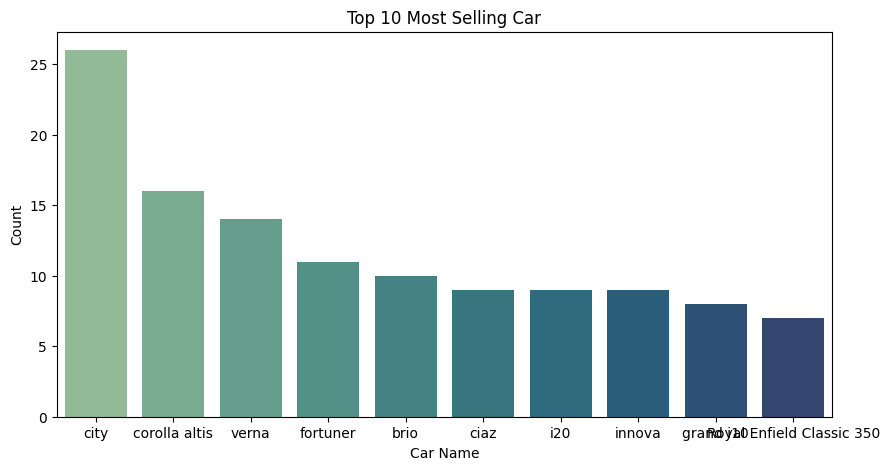

In [139]:
#Visualization
# Top 10 Most Selling Car
top10 = df['Car_Name'].value_counts()[:10]
plt.figure(figsize=(10,5))
sns.countplot(x='Car_Name', data=df, order=top10.index, palette='crest')
plt.xlabel('Car Name')
plt.ylabel('Count')
plt.title('Top 10 Most Selling Car')
plt.show()


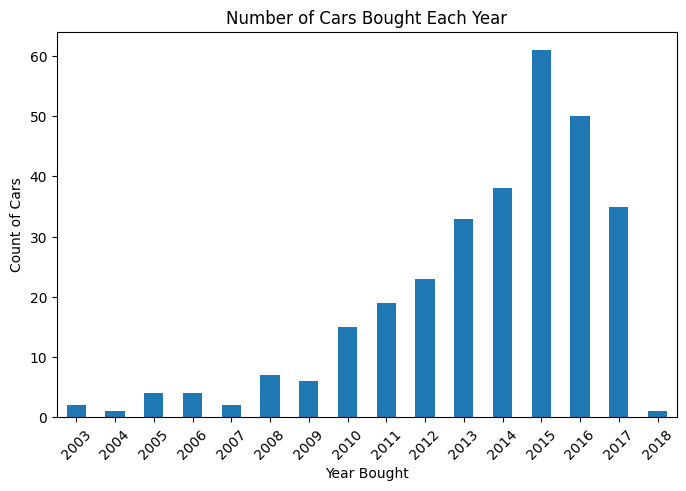

In [140]:
# Visualization – Cars Bought Each Year
# Number of Cars Bought Each Year
plt.figure(figsize=(8,5))
yearly_counts = df.groupby('Year').count()['Car_Name']
yearly_counts.plot(kind='bar')
plt.xticks(rotation=45)
plt.xlabel('Year Bought')
plt.ylabel('Count of Cars')
plt.title('Number of Cars Bought Each Year')
plt.show()


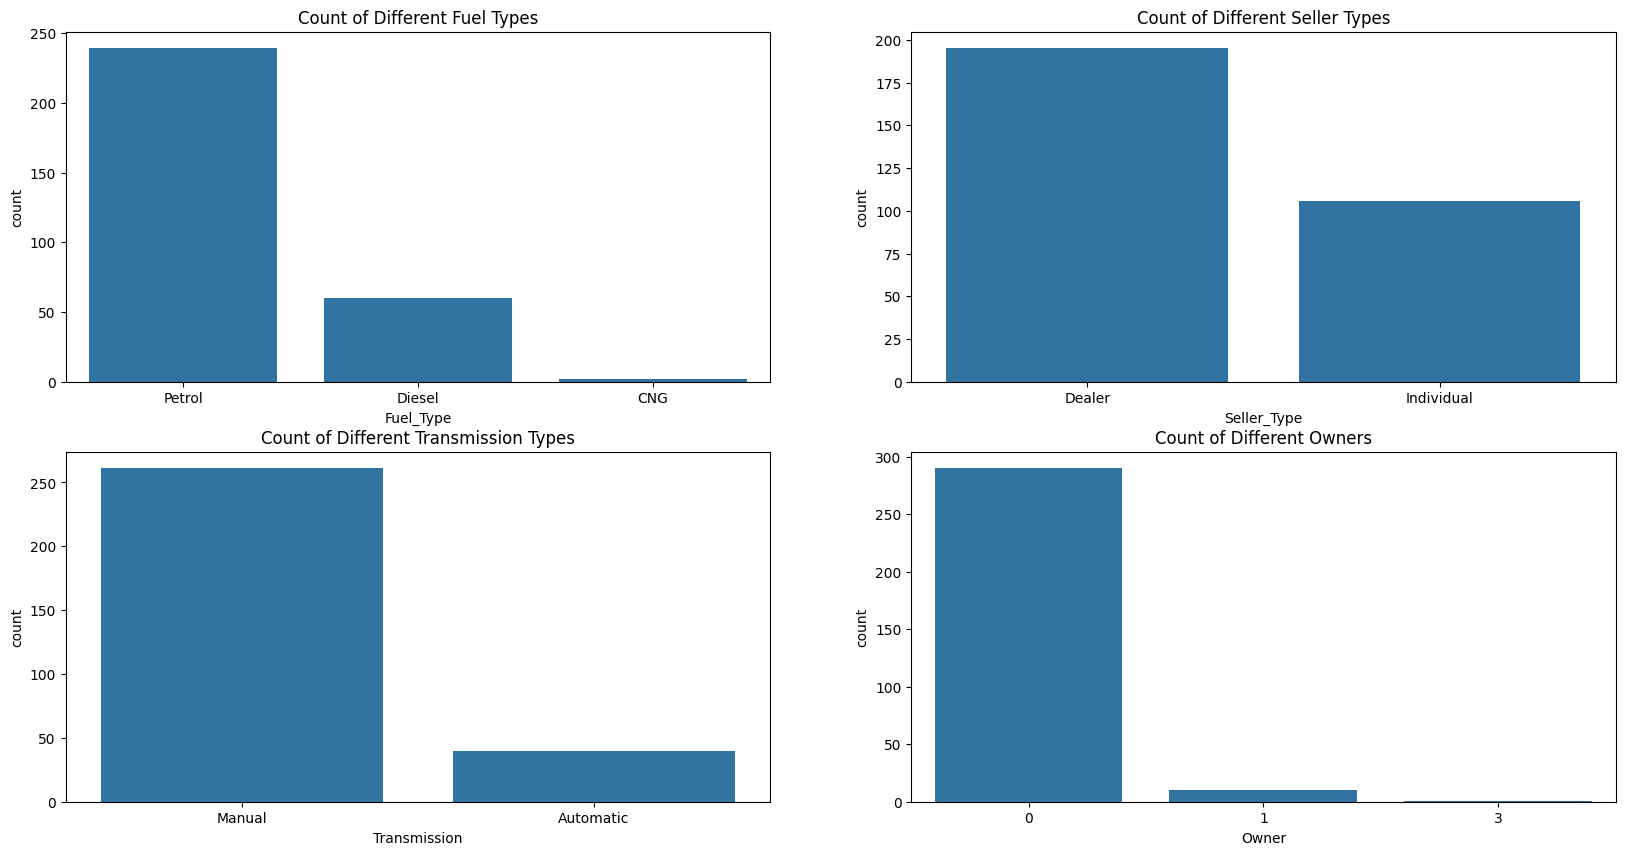

In [141]:
# Distribution of Categorical Variables
plt.figure(figsize=(20,10))

plt.subplot(2,2,1)
sns.countplot(data=df, x='Fuel_Type')
plt.title("Count of Different Fuel Types")

plt.subplot(2,2,2)
sns.countplot(data=df, x='Seller_Type')
plt.title("Count of Different Seller Types")

plt.subplot(2,2,3)
sns.countplot(data=df, x='Transmission')
plt.title("Count of Different Transmission Types")

plt.subplot(2,2,4)
sns.countplot(data=df, x='Owner')
plt.title("Count of Different Owners")

plt.show()


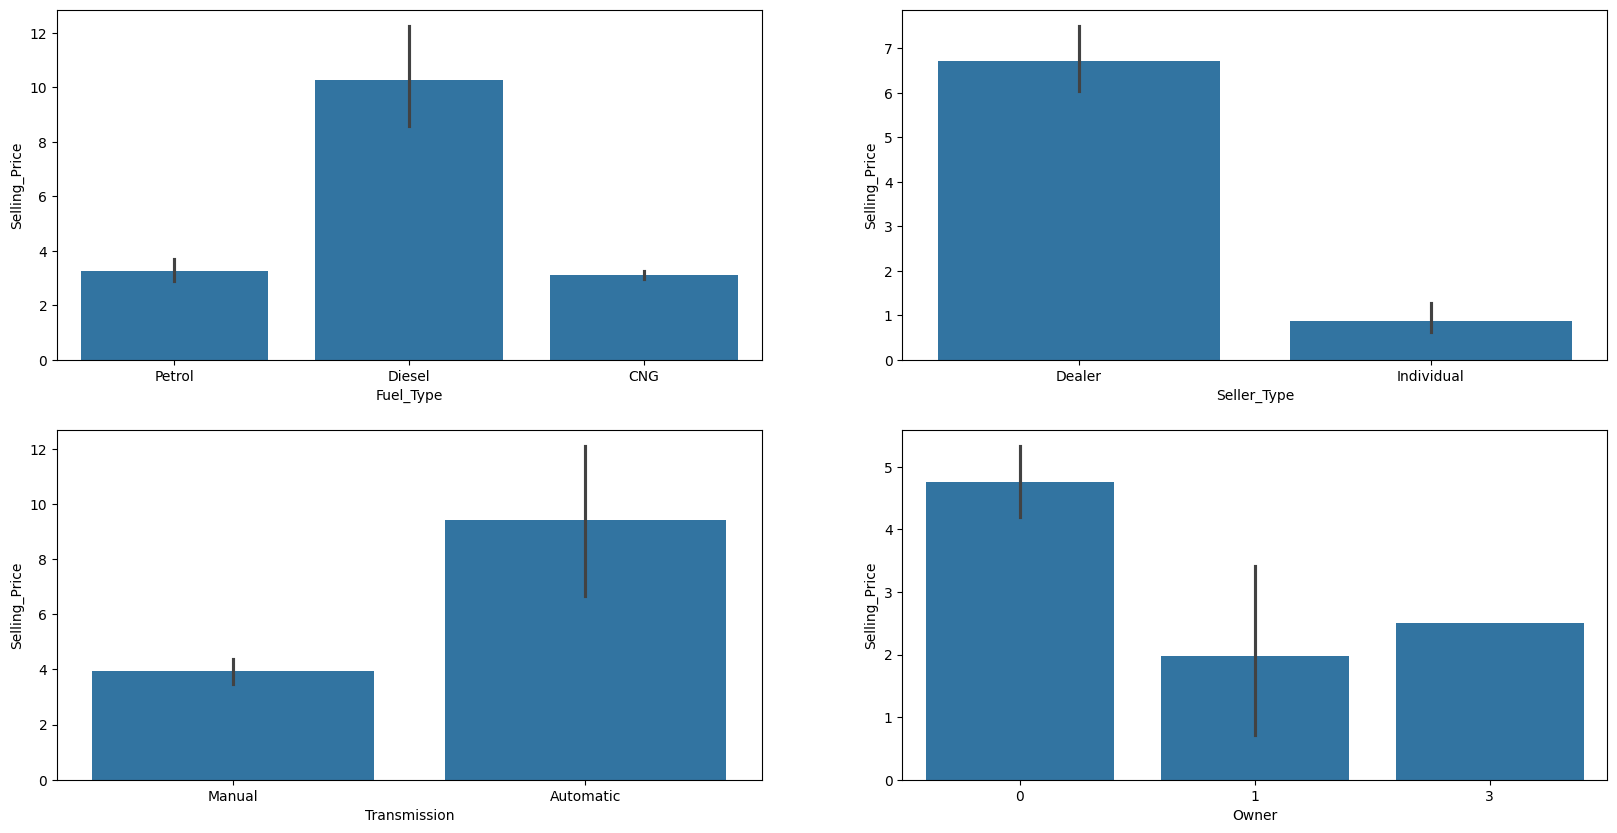

In [142]:
# Selling Price vs Categorical Variables
plt.figure(figsize=(20,10))

plt.subplot(2,2,1)
sns.barplot(data=df, x='Fuel_Type', y='Selling_Price')

plt.subplot(2,2,2)
sns.barplot(data=df, x='Seller_Type', y='Selling_Price')

plt.subplot(2,2,3)
sns.barplot(data=df, x='Transmission', y='Selling_Price')

plt.subplot(2,2,4)
sns.barplot(data=df, x='Owner', y='Selling_Price')

plt.show()


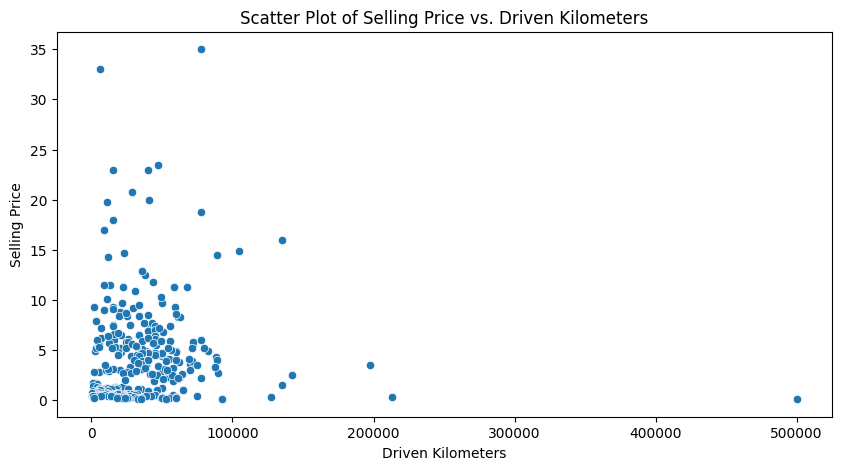

In [143]:
# Scatter Plot – Kms Driven vs Price
# Driven Kilometers vs Selling Price
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='Kms_Driven', y='Selling_Price')
plt.xlabel('Driven Kilometers')
plt.ylabel('Selling Price')
plt.title('Scatter Plot of Selling Price vs. Driven Kilometers')
plt.show()


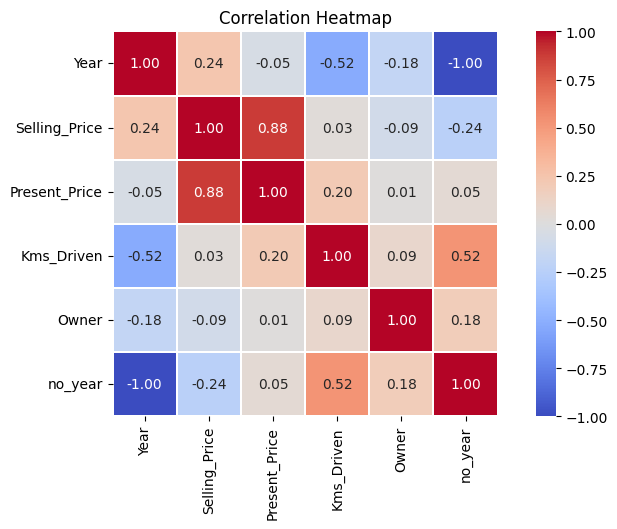

In [144]:
# keep only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Correlation Heatmap visualization code
# Set the size of the plot
plt.figure(figsize=(10, 5))

# Create a heatmap of the correlation matrix with annotations
sns.heatmap(numeric_df.corr(), annot=True, linewidths=0.1, fmt='.2f', square=True, cmap='coolwarm')

# Add a title to the plot
plt.title("Correlation Heatmap")

# Display the plot
plt.show()


In [145]:
# Handling Outliers & Outlier treatments
# Removing outliers by Using IQR method:
q1, q3, median = df.Selling_Price.quantile([0.25,0.75,0.5])
lower_limit = q1 - 1.5*(q3-q1)
upper_limit = q3 + 1.5*(q3-q1)
df['Selling_Price'] = np.where(df['Selling_Price'] > upper_limit, median,np.where(df['Selling_Price'] < lower_limit,median,df['Selling_Price']))

# Removing outliers by Capping:
for col in ['Present_Price','Kms_Driven','Owner','no_year']:
  upper_limit = df[col].quantile(0.99)
  df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])


In [146]:
print(df.columns)

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'no_year'],
      dtype='object')


In [147]:
# Categorical Encoding
df.drop(['Car_Name'], axis=1, inplace=True)
df = pd.get_dummies(df)



In [148]:
# Feature Selection
features = [i for i in df.columns if i not in ['Selling_Price']]
features

['Year',
 'Present_Price',
 'Kms_Driven',
 'Owner',
 'no_year',
 'Fuel_Type_CNG',
 'Fuel_Type_Diesel',
 'Fuel_Type_Petrol',
 'Seller_Type_Dealer',
 'Seller_Type_Individual',
 'Transmission_Automatic',
 'Transmission_Manual']

In [149]:
df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,no_year,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Dealer,Seller_Type_Individual,Transmission_Automatic,Transmission_Manual
0,2014,3.35,5.59,27000.0,0.0,9.0,False,False,True,True,False,False,True
1,2013,4.75,9.54,43000.0,0.0,10.0,False,True,False,True,False,False,True
2,2017,7.25,9.85,6900.0,0.0,6.0,False,False,True,True,False,False,True
3,2011,2.85,4.15,5200.0,0.0,12.0,False,False,True,True,False,False,True
4,2014,4.60,6.87,42450.0,0.0,9.0,False,True,False,True,False,False,True


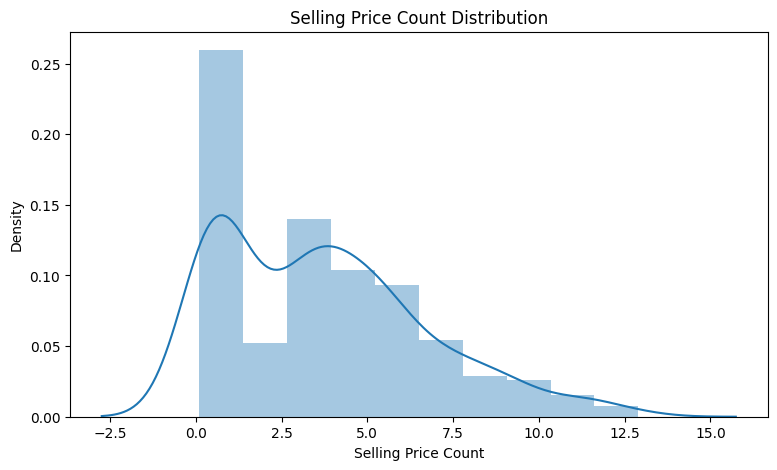

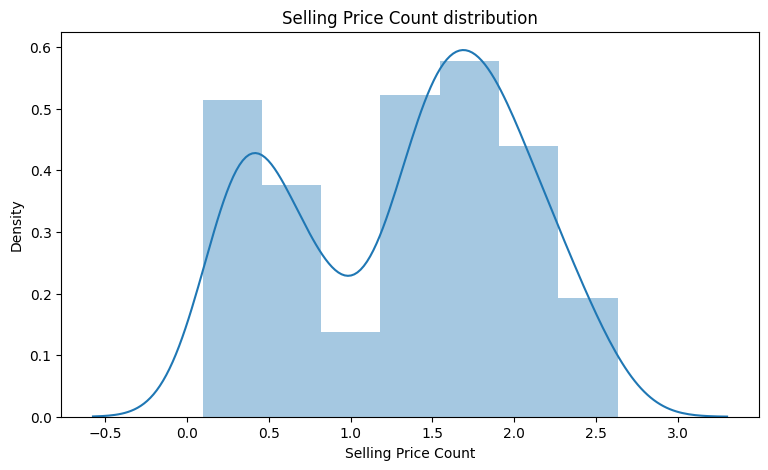

In [150]:
# Selling Price Distribution
plt.figure(figsize=(9,5))
sns.distplot(df[dependent_variable])
plt.xlabel('Selling Price Count')
plt.title('Selling Price Count Distribution')
plt.show()

# Log Transformation
plt.figure(figsize=(9,5))
sns.distplot(np.log1p(df[dependent_variable]))
plt.xlabel('Selling Price Count')
plt.title('Selling Price Count distribution')
plt.show()


Model **Training**

In [151]:
# Defining dependent and independent variables
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [152]:
# Train models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    results[name] = {
        "R2": r2_score(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    }
    print(f"{name}: R² = {results[name]['R2']:.3f}, RMSE = {results[name]['RMSE']:.3f}")

Linear Regression: R² = 0.676, RMSE = 1.673
Ridge: R² = 0.675, RMSE = 1.676
Lasso: R² = 0.356, RMSE = 2.360
Decision Tree: R² = 0.890, RMSE = 0.973
Random Forest: R² = 0.946, RMSE = 0.684
Gradient Boosting: R² = 0.921, RMSE = 0.828
XGBoost: R² = 0.940, RMSE = 0.723


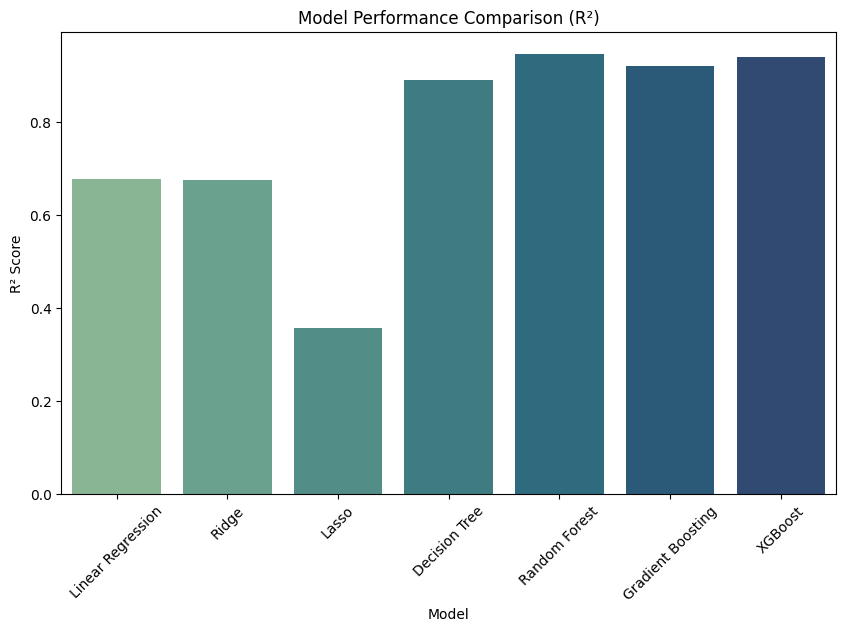

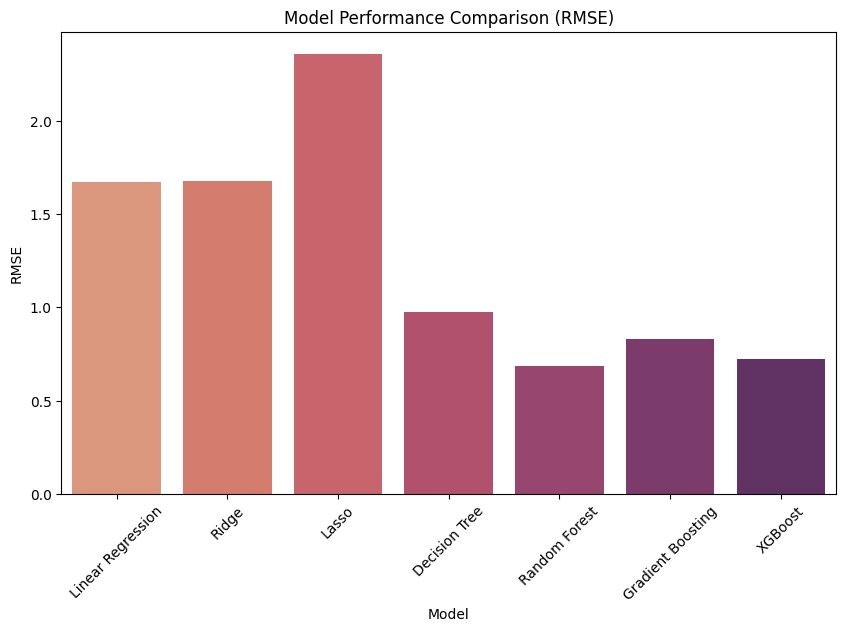

In [153]:
# Metric Score Chart
# This chart compares R² (accuracy) and RMSE (error) for all models.
# It helps us visually identify which model performs best overall.

# Convert results dictionary into a DataFrame for plotting
import pandas as pd

metrics_df = pd.DataFrame(results).T  # transpose so models are rows
metrics_df.reset_index(inplace=True)
metrics_df.rename(columns={'index':'Model'}, inplace=True)

# Plot R² scores
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='R2', data=metrics_df, palette="crest")
plt.xticks(rotation=45)
plt.ylabel("R² Score")
plt.title("Model Performance Comparison (R²)")
plt.show()

# Plot RMSE scores
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='RMSE', data=metrics_df, palette="flare")
plt.xticks(rotation=45)
plt.ylabel("RMSE")
plt.title("Model Performance Comparison (RMSE)")
plt.show()


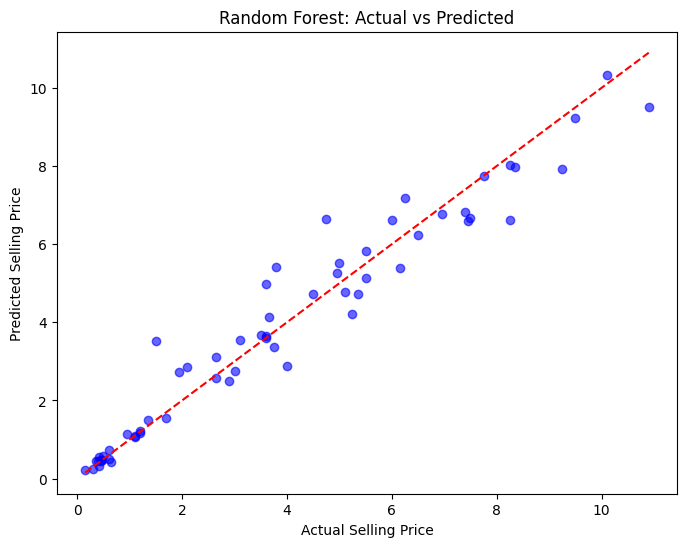

In [154]:
# Actual vs Predicted (Random Forest)
# This scatter plot compares actual car prices with predicted prices.
# The closer the points are to the red diagonal line, the better the fit.

y_pred_rf = predictions["Random Forest"]

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Random Forest: Actual vs Predicted")
plt.show()



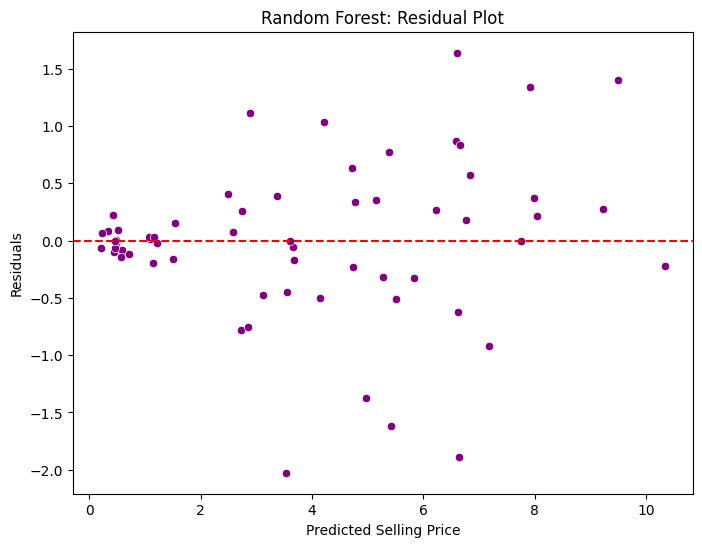

In [155]:
# Residual Plot (Random Forest)
# This plot shows the distribution of errors (residuals).
# A good model should have residuals randomly scattered around zero.

residuals = y_test - y_pred_rf

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred_rf, y=residuals, color='purple')
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Predicted Selling Price")
plt.ylabel("Residuals")
plt.title("Random Forest: Residual Plot")
plt.show()


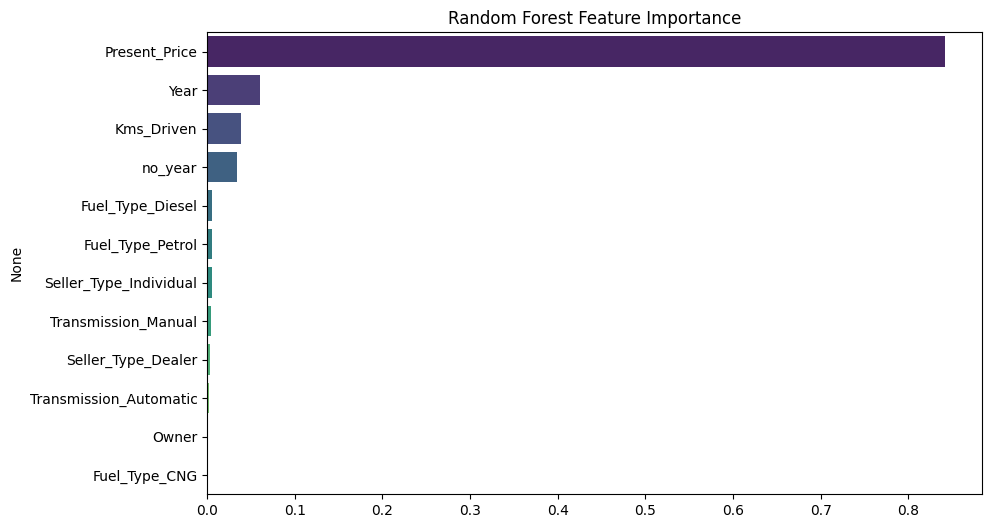

In [156]:
# Feature Importance (Random Forest)
# This bar chart shows which features contribute most to predictions.

rf = models["Random Forest"]
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=X_train.columns[indices], palette="viridis")
plt.title("Random Forest Feature Importance")
plt.show()



In [165]:
# Save the trained Random Forest model

import pickle

rf = models["Random Forest"]   # best performing model
pickle.dump(rf, open('car_price_model.pkl', 'wb'))


In [166]:
print(X_train.columns)


Index(['Year', 'Present_Price', 'Kms_Driven', 'Owner', 'no_year',
       'Fuel_Type_CNG', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol',
       'Seller_Type_Dealer', 'Seller_Type_Individual',
       'Transmission_Automatic', 'Transmission_Manual'],
      dtype='object')


In [167]:
sample = np.array([[2015,        # Year
                    5.59,        # Present_Price
                    27000,       # Kms_Driven
                    0,           # Owner
                    8,           # no_year
                    0,           # Fuel_Type_CNG
                    1,           # Fuel_Type_Diesel
                    0,           # Fuel_Type_Petrol
                    1,           # Seller_Type_Dealer
                    0,           # Seller_Type_Individual
                    0,           # Transmission_Automatic
                    1]])         # Transmission_Manual

print("Predicted Price:", model.predict(sample))


Predicted Price: [4.0595]


In [164]:
import gradio as gr
import numpy as np
import pickle

# Load the trained Random Forest model
model = pickle.load(open('car_price_model.pkl','rb'))

# Prediction function
def predict_car_price(Year, Present_Price, Kms_Driven, Owner, Fuel_Type, Seller_Type, Transmission):
    # Calculate car age
    no_year = 2026 - Year   # adjust to current year if needed

    # One-hot encoding for categorical inputs
    fuel_cng = 1 if Fuel_Type=="CNG" else 0
    fuel_diesel = 1 if Fuel_Type=="Diesel" else 0
    fuel_petrol = 1 if Fuel_Type=="Petrol" else 0
    seller_dealer = 1 if Seller_Type=="Dealer" else 0
    seller_individual = 1 if Seller_Type=="Individual" else 0
    trans_auto = 1 if Transmission=="Automatic" else 0
    trans_manual = 1 if Transmission=="Manual" else 0

    # Build input array in exact training order
    input_data = np.array([[Year, Present_Price, Kms_Driven, Owner, no_year,
                            fuel_cng, fuel_diesel, fuel_petrol,
                            seller_dealer, seller_individual,
                            trans_auto, trans_manual]])

    prediction = model.predict(input_data)
    return f"Predicted Selling Price: {prediction[0]:.2f} lakhs"

# Gradio interface
iface = gr.Interface(
    fn=predict_car_price,
    inputs=[
        gr.Number(label="Year"),
        gr.Number(label="Present Price (in lakhs)"),
        gr.Number(label="Kms Driven"),
        gr.Number(label="Owner Count"),
        gr.Radio(["Petrol","Diesel","CNG"], label="Fuel Type"),
        gr.Radio(["Dealer","Individual"], label="Seller Type"),
        gr.Radio(["Manual","Automatic"], label="Transmission")
    ],
    outputs="text",
    title="Car Price Prediction App"
)

iface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0ab79b49adbc513bad.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
